# Banking on Behaviour - Starter Notebook

This notebook shows you how to load the data and create a valid submission.

Feature engineering, model selection, and validation strategy are up to you.

**Target:** Predict `next_3m_txn_count` for each customer in Test.csv

**Metric:** RMSLE (Root Mean Squared Logarithmic Error)

## 1. Load Data

In [1]:
import pandas as pd
import numpy as np

# Core files
train = pd.read_csv('../data/raw/Train.csv')
test = pd.read_csv('../data/raw/Test.csv')


train.head()
train.shape

(8360, 2)

<Axes: >

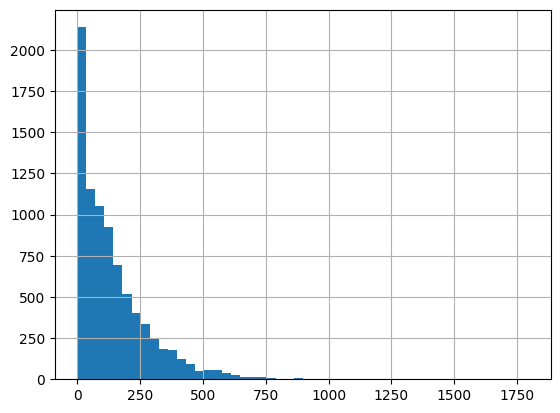

In [2]:
#Understanding the target
train['next_3m_txn_count'].describe()

#checking for missing values
train.isnull().sum() #no missing values

#analysing the skewness of the target variable
train['next_3m_txn_count'].hist(bins=50)

## 2. Explore the Feature Files

In [3]:
# Transaction history (18M rows - this may take a moment)
txn = pd.read_parquet('../data/raw/transactions_features.parquet')

#sampling the data just for analysing to understsandiut
txn_sample = txn.sample(200000)
txn_sample['UniqueID'].nunique() #how many unique customeers in transaction

#msut conbvert transactions → customer-level features
txn_sample.groupby('UniqueID').size().describe()

txn_sample.head()

,UniqueID,AccountID,TransactionDate,TransactionAmount,TransactionTypeDescription,TransactionBatchDescription,StatementBalance,IsDebitCredit,ReversalTypeDescription
4751547,949ce088-5552-478c-a293-3dcbdd1ed227,b83550de-5dfa-4a8d-963d-cb7a1e8c0aac,2015-01-04,-31.83,Transfers & Payments,System Defined,72331.17,Credit,Manual
1358616,bc2c6a01-f44d-4115-befd-02f3fc126e16,301a94b7-85b5-4885-bb88-4029f8a8690e,2015-05-27,-189.57,Transfers & Payments,System Defined,26290.74,Credit,Manual
1010465,3841113f-4b87-4c87-ad80-763d6ba3d686,d57ece15-6d29-448e-b5eb-3d9a4b28f558,2015-10-09,-115.31,Transfers & Payments,System Defined,1155.66,Credit,Manual
17535155,60cf41f6-6dfd-452a-98b5-216e9555cc97,55a09a55-2755-4f86-a152-02dc24b26a29,2013-12-05,-226.56,Transfers & Payments,System Defined,190476.57,Credit,Sytem
6475700,4d9fdc85-1ea9-47b0-a2b5-72b6a244a27c,07366902-851d-42bc-b25d-9b1151b2322f,2014-03-01,-4304.46,Transfers & Payments,System Defined,-37502.30,Credit,Sytem


In [ ]:
#Understanding money behaviour
#grup by customer, select tarnsaction amount and sum the money customer has transacted from Dec 2012 → Oct 2015
#then get summary fo money behaviour
txn_sample.groupby("UniqueID")["TransactionAmount"].sum().describe()

count    1.085200e+04
mean    -5.871716e+03
std      2.502532e+05
min     -2.983549e+06
25%     -3.644200e+04
50%     -1.603310e+03
75%      1.767657e+04
max      2.954749e+06
Name: TransactionAmount, dtype: float64

<Axes: >

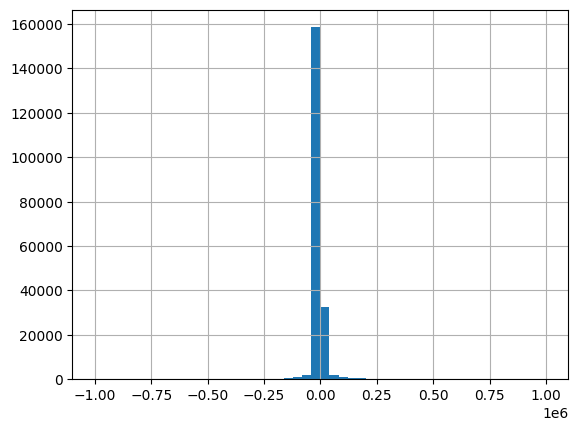

In [6]:
#looking at distribution of transaction amount
txn_sample['TransactionAmount'].hist(bins=50)

In [ ]:
# Financial snapshots
# fin = pd.read_parquet('financials_features.parquet')
# print(f'Financials: {len(fin):,} rows, {fin.UniqueID.nunique():,} customers')
# print()
# print(fin.head())

In [ ]:
# Demographics (one row per customer)
# demo = pd.read_parquet('demographics_clean.parquet')
# print(f'Demographics: {len(demo):,} rows')
# print()
# print(demo.head())

## 3. Your Work Goes Here

This is where you build your solution. Some things to think about:

- How will you aggregate 18M transaction rows into customer-level features?
- Which columns are most useful? Which ones need cleaning?
- How does the prediction window relate to the feature data?
- What modelling approach will you use?

In [ ]:
# Your feature engineering
# ...

# Your model training
# ...

# Your predictions
# ...

## 4. Create a Valid Submission

Your submission must match the format of SampleSubmission.csv exactly.

In [ ]:
submission = pd.read_csv('SampleSubmission.csv')

# Replace this with your actual predictions
submission['next_3m_txn_count'] = train['next_3m_txn_count'].mean()

submission.to_csv('submission.csv', index=False)
print(f'Submission saved: {len(submission)} rows')
print(submission.head())

## Local Scoring

You can score your submission locally using the included evaluate.py script:



Note: PublicReference.csv is only available if you have it for local testing. On Zindi, scoring is automatic.